In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow torch

In [1]:
!pip install -U ipykernel

In [8]:
import pandas as pd
import numpy as np

In [9]:
# Fixando a semente para que os dados gerados sejam sempre os mesmos
np.random.seed(42)

# Gerando 50 idades aleatórias entre 18 e 65 anos
idades = np.random.randint(18, 65, 50)

# Criando salários com uma relação lógica (mais idade = salário maior), mas com um pouco de "ruído"
salarios = 1500 + (idades * 120) + np.random.normal(0, 500, 50)

# Criando a tabela e exportando para CSV
df_sintetico = pd.DataFrame({'Idade': idades, 'Salario': salarios})
df_sintetico.to_csv('dados_salario.csv', index=False)

print("Arquivo 'dados_salario.csv' gerado com sucesso na sua pasta!")

Arquivo 'dados_salario.csv' gerado com sucesso na sua pasta!


In [10]:
df = pd.read_csv('dados_salario.csv') #import csv data

print("\nMostra as primeiras cinco linhas")
df.head() #show the first five rows 

print("\nMostra a tabela inteira")
display(df.sort_values(by='Idade'))

print("\nMostra as informações da tabela")
df.info() #show infos about the table

print("\nMostra coluna especifica da tabela, adicionada ao metodo head")
df['Salario'].head() #show especific column and some informations


Mostra as primeiras cinco linhas

Mostra a tabela inteira


,Idade,Salario
17,19,4374.312863
48,19,3313.118580
22,19,4010.408150
15,20,3814.185582
36,20,4231.142257
43,21,4636.748402
38,24,4295.897456
4,25,4306.763525
46,26,3597.788489
40,26,4497.126156



Mostra as informações da tabela
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Idade    50 non-null     int64  
 1   Salario  50 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 932.0 bytes

Mostra coluna especifica da tabela, adicionada ao metodo head


0    8609.596317
1    6469.451122
2    5905.114097
3    8886.559457
4    4306.763525
Name: Salario, dtype: float64

No âmbito da IA, temos as features e labels, cada um possui uma responsabilidade. sendo as features (X em uma função): valores caracteristicos onde a IA tirará conclusões, nesse caso, idade. labels (y em uma função): valores que a IA tentará prever, nesse caso, salário.

Nesse sentido, precisamos fazer um modelo que prevê o salário de alguem em função da idade. 

In [11]:
#criaremos o X
idade = df[['Idade']] #necessário em uma matriz para entrada de dados do scikit-learn de tabela 2D seja estruturados.

#criaremos o y
salario = df['Salario'] #label geralmente é um vetor 1D para a comparação.

In [12]:
#esse chamada importa um embaralhador e dividor de dados, para que a IA estude uma e teste a outra.
#a label faz a validação dos dados, o restante faz o teste e o treino.
from sklearn.model_selection import train_test_split

#a função de treino divide os dados de cada coluna em dois
X_treino, X_teste, y_treino, y_teste = train_test_split(idade, salario, test_size = 0.2, random_state = 42)

print(X_treino.shape) #mostra a quantidade de linhas e colunas

(40, 1)


In [ ]:
#carrega o modelo que faz a regressão linear
from sklearn.linear_model import LinearRegression

#instanciação do modelo
model = LinearRegression()

#cruzamento de dados e treina o modelo, x com y.
model.fit(X_treino, y_treino) 

#pede para a IA treinar com os 10 dados (de teste) que ela nunda viu antes. 
previsaoTeste = model.predict(X_teste)

#um dado completamento novo.
previsaoTrinta = model.predict([[30]])

print(previsaoTeste)
print(previsaoTrinta)


[8351.02083237 6041.91125117 8594.08499881 5191.18666862 3732.80166997
 3732.80166997 6163.44333439 4948.12250218 5434.25083507 8837.14916525]
[5069.6545854]


/Users/apple/LearningAI/venv_ia/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
#calculo númerico do erro
from sklearn.metrics import mean_absolute_error

#calcula o teste e a previsão da IA
mae = mean_absolute_error(y_teste, previsaoTeste)

print(f"Erro Absoluto Médio (MAE): {mae:.2f}")

Erro Absoluto Médio (MAE): 599.42


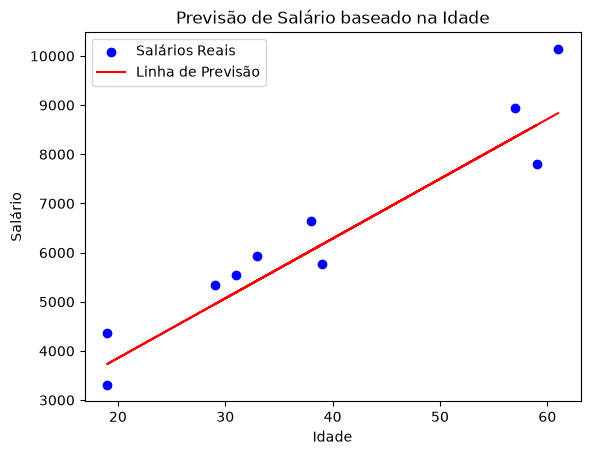

In [15]:
#gráfico do erro
import matplotlib.pyplot as plt

#desenha os gráficos reais
plt.scatter(X_teste, y_teste, color = 'blue', label = 'Salários Reais')

#desenha gráfico contínuo
plt.plot(X_teste, previsaoTeste, color = 'red', label = 'Linha de Previsão')

#adiciona título e legenda
plt.title('Previsão de Salário baseado na Idade')
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.legend()

#Aparece o gráfico na telaa
plt.show()

In [16]:
from sklearn.metrics import r2_score

#métrica de porcentagem da precisão do modelo
r2 = (r2_score(y_teste, previsaoTeste) * 100)

print(f"{r2:.2f}%")

88.80%
